### Problem definition

The goal of this analysis aims to predict house insurance premium amounts a customer would be charged based on the premises attributes using machine learning models. The model will identify the most important risk factors and help in estimating premiums.

### Project Overview

**Objective:** Build a predictive model for insurance premium amounts.

**Approach:**
- STEP 1: Exploratory Data Analysis (EDA)
- STEP 2: Data Engineering
- STEP 3: Model Training & Performance Evaluation

**Improvements**
- Ideas on how we can further improve the model predictions

### Dataset description

**Numerical data**

- PREMISES_BATHROOMS                    (number of bathrooms of the property)
- PREMISES_BEDROOMS                     (number of bedrooms of the property)
- PREMISES_REBUILD_COST                 (How much it costs to re-build the property)
- PREMISES_YEARS_RESIDENCY              (number of years lived in the property)
- PREMISES_YEAR_BUILT                   (when the premise was built)
- PREMISES_LISTED_IND                   int64
- POTENTIAL_PREMIUM                     (modeled insurance premium)
- MARKET_PREMIUM                        (market insurance premium)

**Categorical data**
- PREMISES_ADDRESS                     (Address of the premise)
- PREMISES_RISK_CODE                   (Post code of the premise)
- PREMISES_PROPERTY_TYPE               (property type)
- PREMISES_NEIGHBOURHOOD_WATCH_IND     (part of a Neighbourhood Watch scheme)

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
DATA_PATH = Path('.')

In [8]:
insurance_path = DATA_PATH / 'raw' / 'GeoData_Scientist_Interview_Task.xlsx'

df_property = pd.read_excel(insurance_path, sheet_name="property_data")
df_flood = pd.read_excel(insurance_path, sheet_name="flood_data")

## STEP 1: Exploratory Data Analysis (EDA)

#### Check basic statistics of the data

In [4]:
df_property.describe()

,PREMISES_BATHROOMS,PREMISES_BEDROOMS,PREMISES_REBUILD_COST,PREMISES_YEARS_RESIDENCY,PREMISES_YEAR_BUILT,PREMISES_LISTED_IND,POTENTIAL_PREMIUM,MARKET_PREMIUM
count,3990.000000,3990.000000,3779.000000,3990.000000,3990.000000,3990.0,3990.000000,3990.000000
mean,1.758647,3.151128,244966.449854,14.190476,1957.281203,3.0,161.285612,186.801336
std,0.808977,0.796374,86251.276836,13.796894,32.284236,0.0,77.924786,88.575167
min,0.000000,1.000000,35000.000000,0.000000,1780.000000,3.0,48.420000,35.810000
25%,1.000000,3.000000,193000.000000,3.000000,1936.000000,3.0,115.600000,126.440000
50%,2.000000,3.000000,225000.000000,10.000000,1963.000000,3.0,140.500000,165.145000
75%,2.000000,4.000000,275000.000000,22.000000,1978.000000,3.0,182.257500,227.237500
max,7.000000,5.000000,999999.000000,88.000000,2021.000000,3.0,943.890000,834.900000


**Key insights**

- we observe that mainly the data for the column names `PREMISES_REBUILD_COST` and `PREMISES_YEARS_RESIDENCY` appear to be right skewed when we observe the difference between the **mean** and **50%**
- The data appear to have some outliers such as `max number of bathrooms 7`, `premise rebuild cost 999999` or `years of residency 88`
- Market premium is higher on average than the modelled potential premium. It is also interesting to see that the model can price premiums higher than the market when we look at the max value

### Missing values

In [4]:
missing_values = df_property.isnull().sum()  
missing_percentage = (missing_values / len(df_property)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
# identify rows with missing values
missing_rows = df_property.loc[df_property.isnull().any(axis=1)]
missing_df


,Missing Values,Percentage
PREMISES_ADDRESS,0,0.000000
PREMISES_RISK_CODE,0,0.000000
PREMISES_BATHROOMS,0,0.000000
PREMISES_BEDROOMS,0,0.000000
PREMISES_PROPERTY_TYPE,0,0.000000
PREMISES_REBUILD_COST,211,5.288221
PREMISES_YEARS_RESIDENCY,0,0.000000
PREMISES_YEAR_BUILT,0,0.000000
PREMISES_LISTED_IND,0,0.000000
PREMISES_NEIGHBOURHOOD_WATCH_IND,0,0.000000


**Key insights**

- There are some missing values only for the column name premise rebuild cost.
- This requires careful consideration as to whether we impute missing values or use models such as XGBoost or LightGBM that can natively handle missing values

### Check the distribution of the data

we need to understand:
- shape of the data (normal, skewed, bimodal)
- Detect outliers that could affect predictions
- Perform transformations to handle highly skewed data
- Spot data entry errors (e.g., extremely large or negative values where not expected)

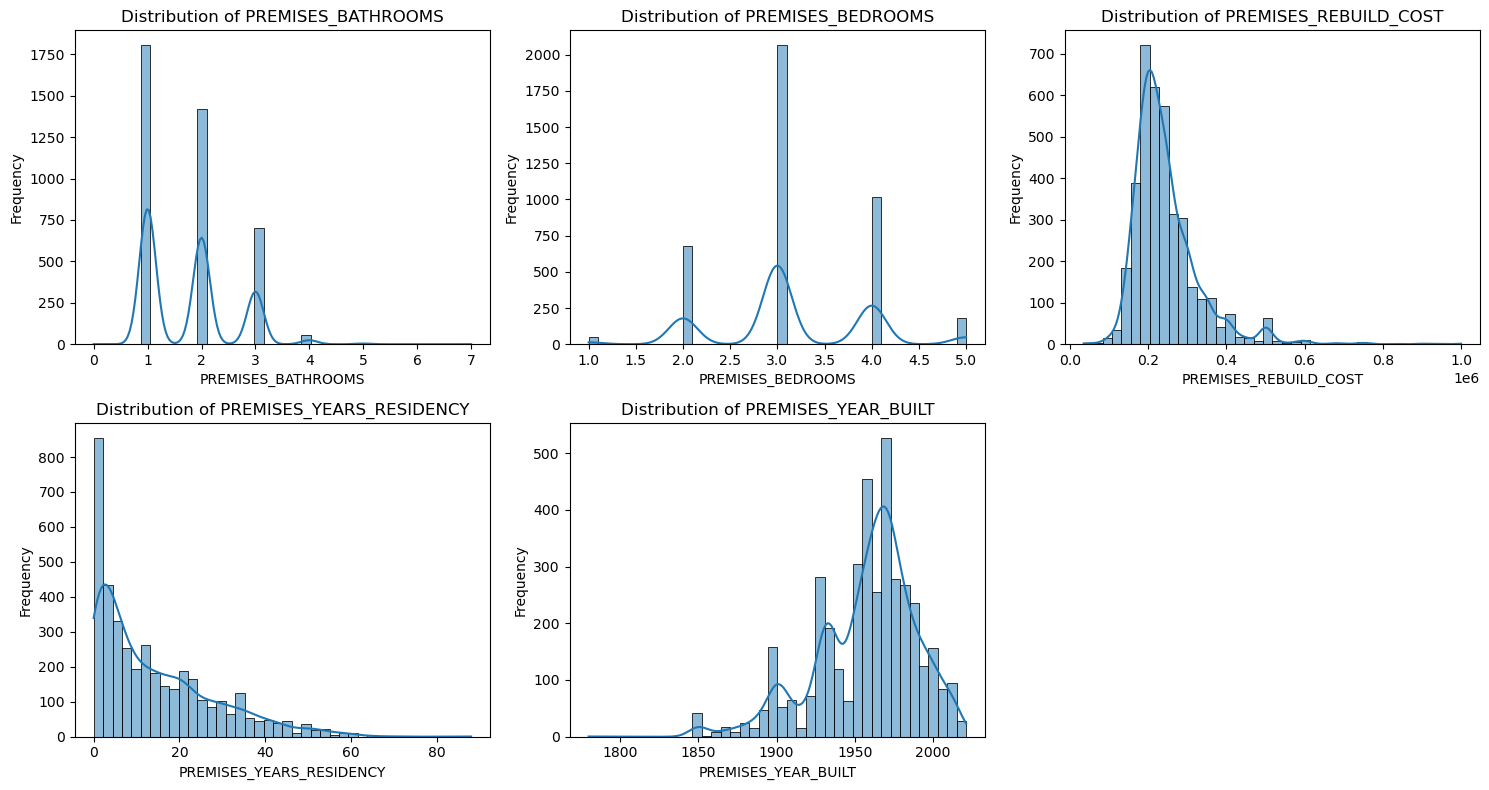

In [49]:
# Select Numerical Features
df_numerical = df_property.select_dtypes(include=["float64","int64"]).columns.tolist()

# Remove the target if it's in the list
to_remove = ["MARKET_PREMIUM", "POTENTIAL_PREMIUM", "PREMISES_LISTED_IND"]
for col in to_remove:
    if col in df_numerical:
        df_numerical.remove(col)

# Plot all numerical features together
n_cols = 3  
n_rows = (len(df_numerical) + n_cols - 1) // n_cols  # calculate needed rows

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for idx, col in enumerate(df_numerical, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.histplot(df_property[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()

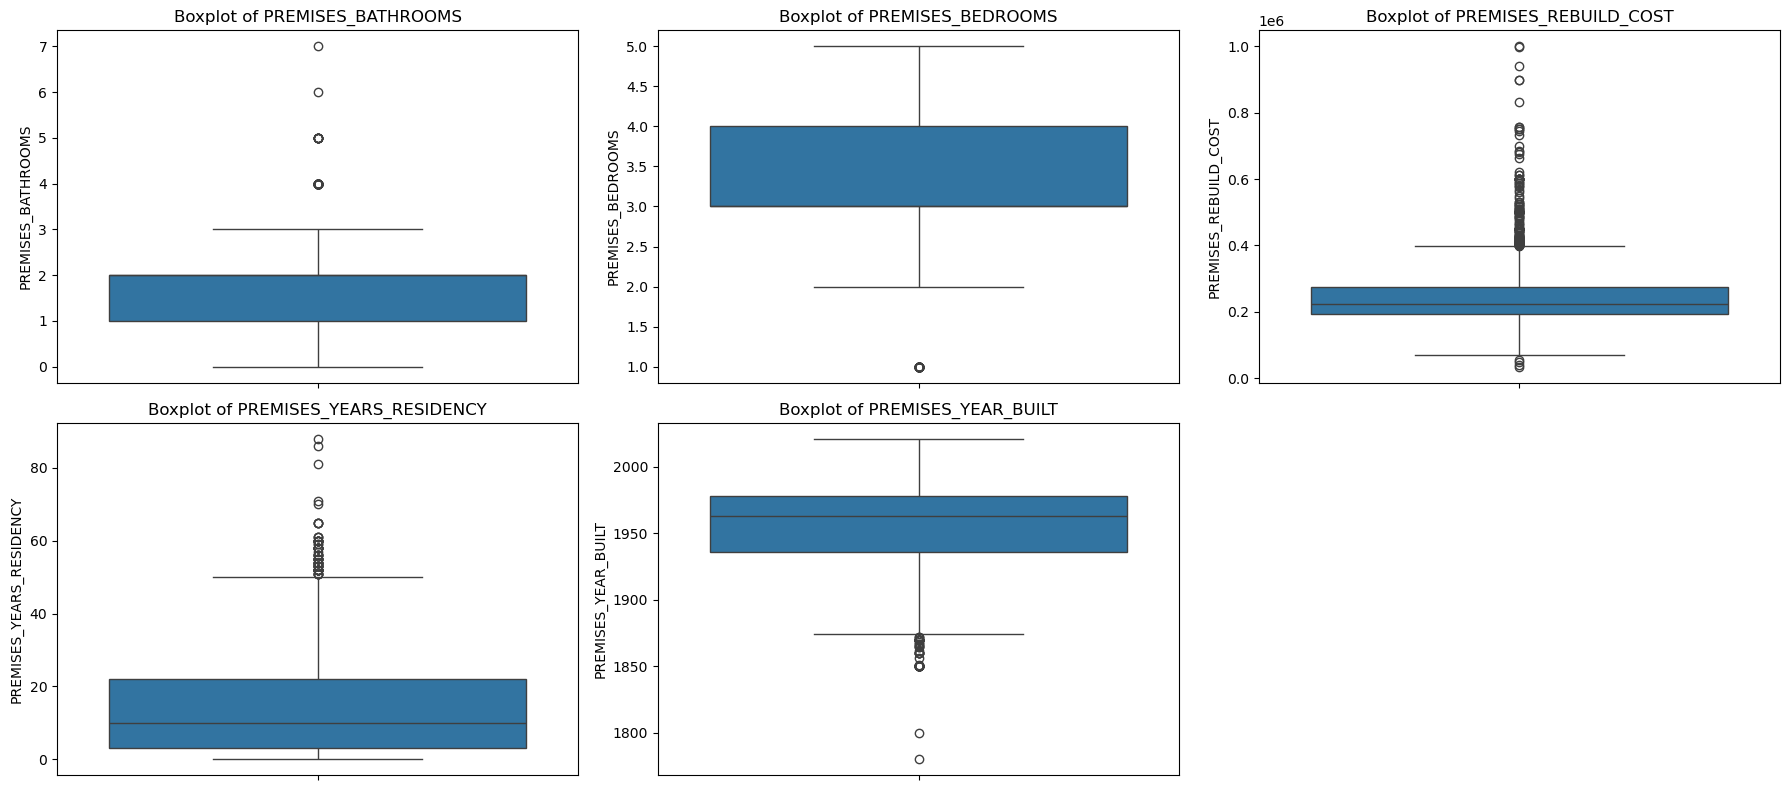

In [ ]:
# check for outliers using boxplots
n_cols = 3  
n_rows = int(np.ceil(len(df_numerical) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))  # Adjust figure size
axes = axes.flatten()

# Plot each numerical feature
for idx, col in enumerate(df_numerical):
    sns.boxplot(data=df_property, y=col, ax=axes[idx])
    axes[idx].set_title(f"Boxplot of {col}")

# Hide any empty subplots
for i in range(len(df_numerical), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

**Key insights**

- We can see that there are skewed features and outliers (e.g., premises_years_residency, premises_rebuild_cost). This requires transformation or models (e.g., XGBoost, LightGBM) that can handle skewed numerical features naturally.
- The feature `premises_rebuild_cost` appears to be the only feature that contains values that are very high (maybe few outliers)

### Check the distribution of the target value

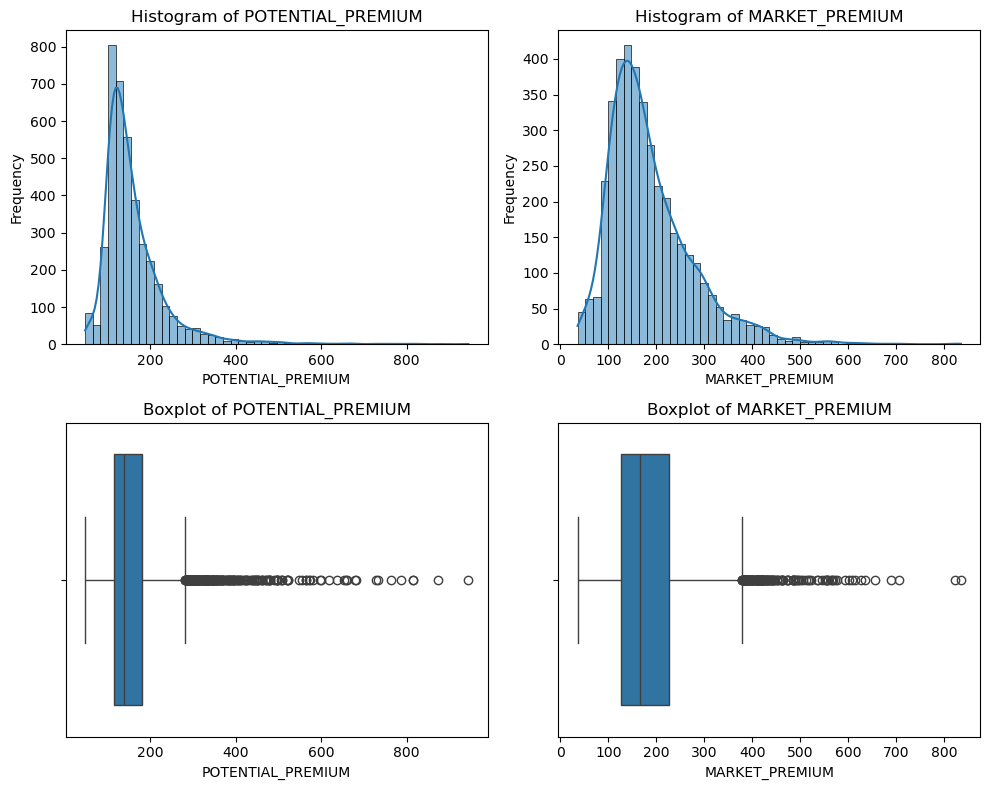

In [ ]:
cols = ['POTENTIAL_PREMIUM', 'MARKET_PREMIUM']

## add two rows: one for histograms and one for boxplots
n_cols = 2
n_rows = 2  

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

# First row: histograms
for idx, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, idx + 1)
    sns.histplot(df_property[col], bins=50, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

# Second row: boxplots
for idx, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, n_cols + idx + 1)  # shift to second row
    sns.boxplot(x=df_property[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**Key inishgts**
- `Right skewed data:` Most premises have relatively low to moderate premiums, but a small number of premises have very large premiums (above 600)
- `Wide spread:` Premiums vary significantly from low to high, consistent with what we saw in the histogram
- `comparison:` We see that the whiskers of **market premium** values are longer than that of **potential premiums** which indicates the value are more spread towards higher premiums and there is higher skewness
- `Log transformation`: This helps to compresses those large premium values and makes the target variable easier for the model to learn.

In [ ]:
outliers = df_property[df_property['POTENTIAL_PREMIUM'] > 600]
detach = df_property[df_property['PREMISES_PROPERTY_TYPE'].str.contains('House - Detached', case=False, na=False)]


### Correlation matrix

We need to check for multi-collinearity (features that might be highly correlated):
- multi-collinearity features happen when two or more features are strongly correlated with each other. If two variables are highly correlated (correlation > 0.8 or < -0.8), they carry redundant information.
- If there are two highly correlated features, we can either drop one of them or combine them in another column

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

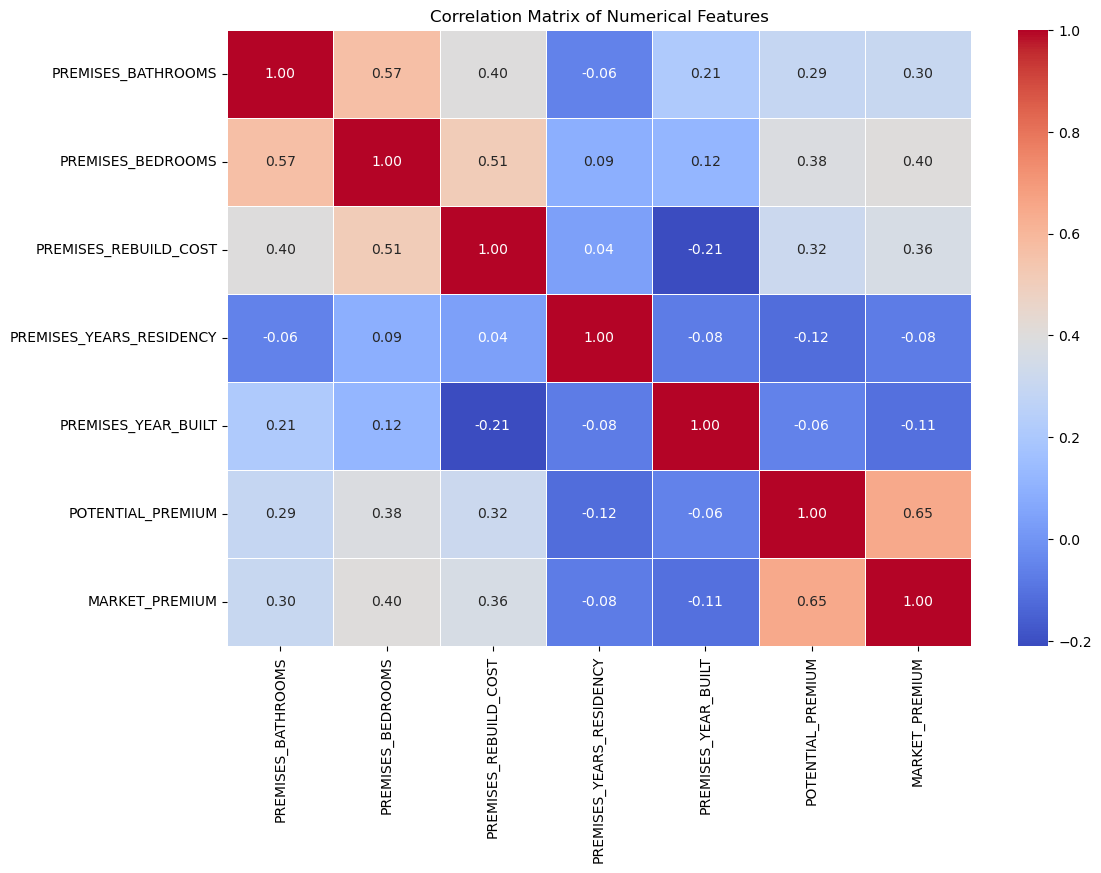

In [10]:
# Select Numerical Features
df_numerical = df_property.select_dtypes(include=["float64","int64"])
# drop this column as it is binary . All rows hve teh same value
df_numerical = df_numerical.drop(columns=["PREMISES_LISTED_IND"], errors='ignore')

# Compute the correlation matrix
corr_matrix = df_numerical.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")


**Key insights**

- Features show little to no correlation with each other.
- We keep all the features for modelling
- We can skip dimensionality reduction (such as PCA)
- we notice that the **premises bedrooms** is the only feature that correlates with the **target feature** which is potential premium (0.4). This indicates that this feature is important for our modelling

### Compare potential premium with the market premium

This analysis will give us an idea of cases where we might underestimated or overestimated insurance premiums based on the market. To do that, we will produce the following plots

- Histogram that shows the difference between potential and market premiums
- Scatter plot (model vs market) with the `line y = x`. Points that fall below the line indicates that we **overestimated** premiums where points above the line indicates that we **underestimated** premiums

Text(0, 0.5, 'Frequency')

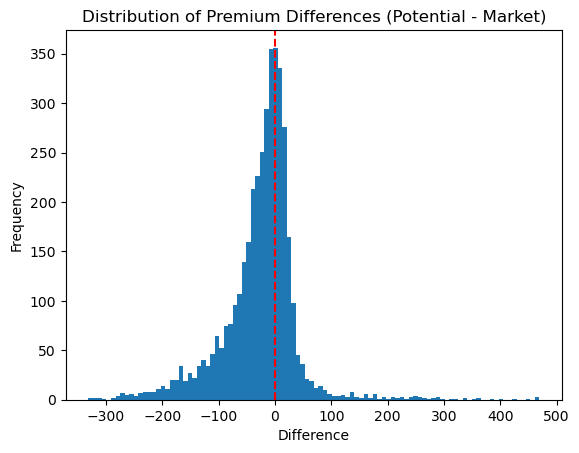

In [28]:
df_property['difference'] = df_property['POTENTIAL_PREMIUM'] - df_property['MARKET_PREMIUM']
plt.hist(df_property['difference'], bins=100)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Premium Differences (Potential - Market)')
plt.xlabel('Difference')
plt.ylabel('Frequency')

In [29]:
print(f"Overestimates: {(df_property['difference'] > 0).sum()}, Underestimates: {(df_property['difference'] < 0).sum()}")

Overestimates: 1381, Underestimates: 2609


In [30]:
# how far off are we across the entire portfolio
df_property['pct_diff'] = (df_property['difference'] / df_property['MARKET_PREMIUM']) * 100
print(f"Mean percentage difference: {df_property['pct_diff'].mean()}")

Mean percentage difference: -7.936149092687882


In [9]:
# show me only those premises where the potential premium is much higher than the market premium by more than 300
df_property.loc[df_property['difference'] > 300, ['PREMISES_PROPERTY_TYPE','MARKET_PREMIUM', 'POTENTIAL_PREMIUM']]

,PREMISES_PROPERTY_TYPE,MARKET_PREMIUM,POTENTIAL_PREMIUM
455,House - Semi-detached,261.94,598.25
464,House - Detached,365.90,727.43
472,House - Terraced,190.76,547.16
474,House - Detached,409.96,872.74
480,House - Terraced,211.33,571.21
481,House - Detached,345.93,815.29
489,House - Detached,293.35,617.72
491,House - Detached,393.61,815.32
492,Bungalow,226.38,678.31
495,House - Detached,182.37,493.54


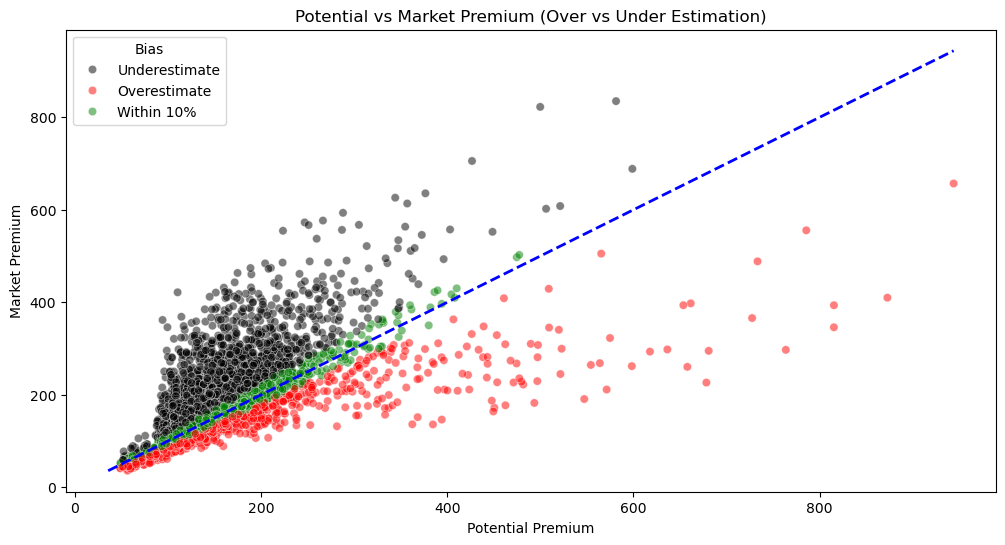

In [31]:
df_property['pct_error'] = (df_property['POTENTIAL_PREMIUM'] - df_property['MARKET_PREMIUM']) / df_property['MARKET_PREMIUM']

df_property['bias'] = np.where(
    df_property['pct_error'].abs() <= 0.10,
    'Within 10%',
    np.where(
        df_property['pct_error'] > 0.10,
        'Overestimate',
        'Underestimate'
    )
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_property,
    x='POTENTIAL_PREMIUM',
    y='MARKET_PREMIUM',
    hue='bias',
    palette={
        'Within 10%': 'green',
        'Overestimate': 'red',
        'Underestimate': 'black'
    },
    alpha=0.5
)   

# Add the reference line (y = x)
min_val = min(df_property['POTENTIAL_PREMIUM'].min(), df_property['MARKET_PREMIUM'].min())
max_val = max(df_property['POTENTIAL_PREMIUM'].max(), df_property['MARKET_PREMIUM'].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, color='blue')

plt.xlabel('Potential Premium')
plt.ylabel('Market Premium')
plt.title('Potential vs Market Premium (Over vs Under Estimation)')
plt.legend(title='Bias')

In [ ]:
# Check the premium percentage difference by property type
group_by_property = df_property.groupby('PREMISES_PROPERTY_TYPE')['pct_diff'].mean()
group_by_property

PREMISES_PROPERTY_TYPE
Bungalow                 -8.744343
Flat                     13.085549
House - Detached         -7.794053
House - Semi-detached    -8.665454
House - Terraced         -7.586132
Name: pct_diff, dtype: float64

**Key insights**
- **Difference between potential and market premiums:** The plot shows that premiums for a higher number of premises have been underestimated (2609), while premiums for fewer premises have been overestimated (1381)
- **how far off are we across the entire portfolio:** Regarding the entire portfolio, we can see that we are pricing 8% lower than market on average
- **difference by property type:** Regarding the premium differences for each property type, we tend to underestimate insurance premiums (by roughly 8%) except flat which we overestimated by 13%  

### Flood risk analysis

In this step, we combine the flood data with the property data into a single dataframe. We are testing the following:
- Do premiums behave as if flood risk was considered?
- Check visually to see if premiums increase with flood risk
- Check correlation between flood risks and premiums

In [22]:
def clean_postcode(pc):
    """ Remove the space in the letters of the postcode"""
    return pc.str.replace(" ", "", regex=False).str.upper()

def aggregate(column):
    flood_agg = df_flood.groupby(column).agg({
        "FLOOD_RISK_1": "median",
        "FLOOD_RISK_2": "median",
        "FLOOD_RISK_3": "median",
        "LATITUDE": "mean",
        "LONGITUDE": "mean"
    }).reset_index()

    return flood_agg

In [23]:
# change PREMISES_RISK_CODE to POSTCODE to match the flood data
df_property = df_property.rename(columns={'PREMISES_RISK_CODE': 'POSTCODE'})
# remove gaps in postcode
df_property["POSTCODE"] = clean_postcode(df_property["POSTCODE"])
df_flood["POSTCODE"] = clean_postcode(df_flood["POSTCODE"])
# merge property with flood data
flood_agg = aggregate("POSTCODE")
df = df_property.merge(flood_agg, on='POSTCODE', how='left')

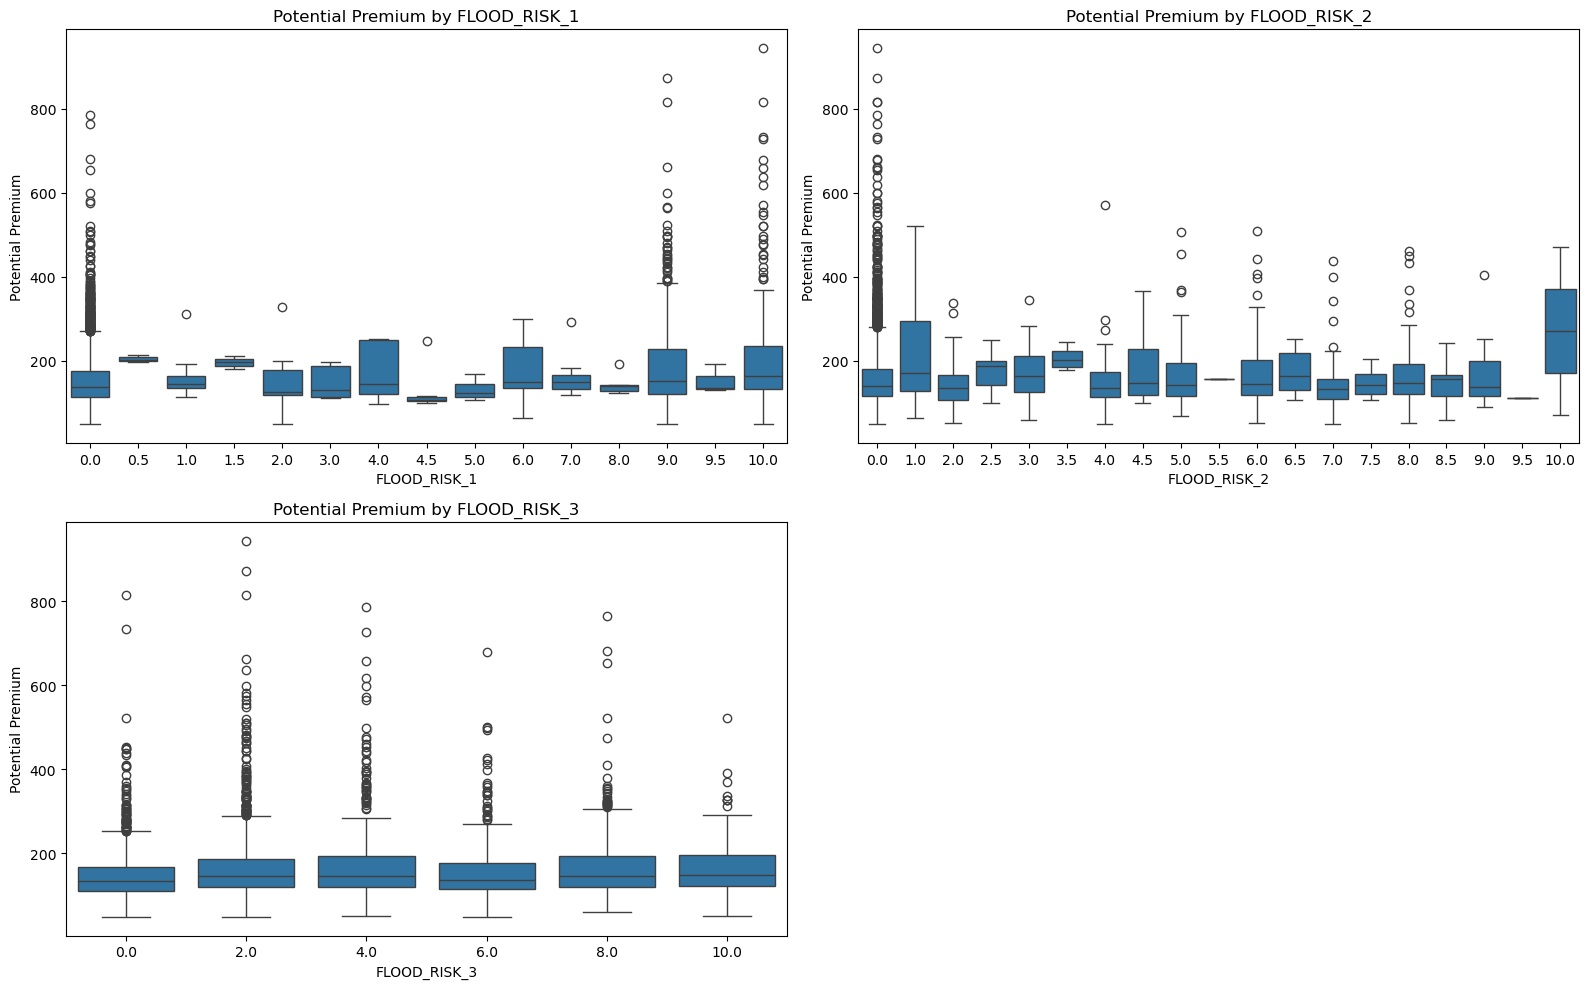

In [123]:
cols_flood = ['FLOOD_RISK_1', 'FLOOD_RISK_2', 'FLOOD_RISK_3']

## add two rows: one for histograms and one for boxplots
n_cols = 2
n_rows = 2  

plt.figure(figsize=(8 * n_cols, 5 * n_rows))


# Second row: boxplots
for idx, col in enumerate(cols_flood):
    plt.subplot(n_rows, n_cols, idx + 1)
    sns.boxplot(data=df, x=col, y='POTENTIAL_PREMIUM')
    plt.title(f'Potential Premium by {col}')
    plt.xlabel(col)
    plt.ylabel('Potential Premium')

plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix of Flood Risk and Premiums')

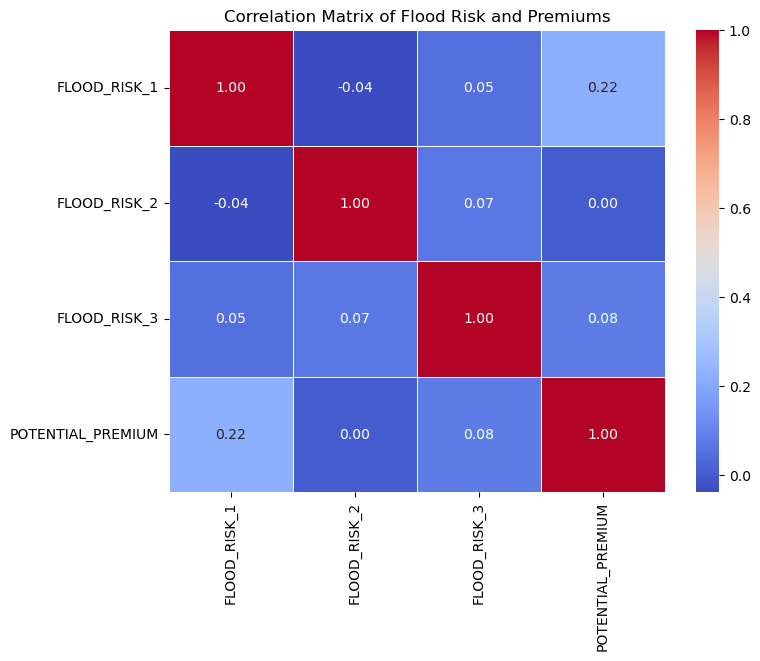

In [124]:
flood_numerical = df[['FLOOD_RISK_1','FLOOD_RISK_2','FLOOD_RISK_3' ,'POTENTIAL_PREMIUM']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(flood_numerical, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Flood Risk and Premiums")

In [18]:
df[df['difference'] > 400][['PREMISES_PROPERTY_TYPE', 'POTENTIAL_PREMIUM', 'MARKET_PREMIUM', 'FLOOD_RISK_1', 'FLOOD_RISK_2', 'FLOOD_RISK_3']]

,PREMISES_PROPERTY_TYPE,POTENTIAL_PREMIUM,MARKET_PREMIUM,FLOOD_RISK_1,FLOOD_RISK_2,FLOOD_RISK_3
967,House - Detached,872.74,409.96,9.0,0.0,2.0
968,House - Detached,872.74,409.96,9.0,0.0,2.0
969,House - Detached,872.74,409.96,9.0,0.0,2.0
970,House - Detached,872.74,409.96,9.0,0.0,2.0
971,House - Detached,872.74,409.96,9.0,0.0,2.0
...,...,...,...,...,...,...
1522,Bungalow,678.31,226.38,9.0,0.0,6.0
1523,Bungalow,678.31,226.38,10.0,0.0,6.0
1524,Bungalow,678.31,226.38,9.0,0.0,6.0
1525,Bungalow,678.31,226.38,10.0,0.0,6.0


**Issues with flood risk data:** 

Before combining flood data with property data, I have noticed the following things that need fixing:
1. There is `one to many` relationship between property and flood data, for instance, cases where a postcode in property data corresponds to one address while in flood data, the same post code corresponds to many address
2. The postcode column for flood data are formatted without spaces (e.g TW170JF), whereas in the property data, the same postcodes include a space (e.g TW17 0JF). This causes issues (ending up with NaN values) when trying to merge both dataset

**Fix the issues:**
1. We aggregated the flood data to postcode level. Otherwise, merging the raw flood data will end up in duplicate property rows, which can bias our model
2. The postcodes of both dataset have been formatted so that there is no space

**Key insights**
- From the boxplots, we can see that the potential premium values especially for flood risk 1 (flood risk values 9 and 10) are very high
- Looking at the correlation map, we see that there is a small correlation between potential premiums and flood risk 1
- Given that the difference between potential and market premiums is so big, this potentially indicates that during the modelling, the scientist included the flood risk in the modelling.

## STEP 2: Data Engineering

#### Feature Engineering

We can derive some other features based on the existing features in our data. Feature engineering can be important step as it can improve model performance. Below we see the newly derived features
- Premise age
- Ratio: bedrooms over bathrooms
- New home owners
- Long term residents

In [16]:
current_year = 2026
df['PREMISES_AGE'] = current_year - df['PREMISES_YEAR_BUILT']
df['ratio_rooms_over_bath'] = df['PREMISES_BEDROOMS'] / (df['PREMISES_BATHROOMS']+1)
df['new_homeowner'] = (df['PREMISES_YEARS_RESIDENCY'] < 2).astype(int)
df['long_term_resident'] = (df['PREMISES_YEARS_RESIDENCY'] > 10).astype(int)

### Action Points from the Data Analysis
- Log-transform the target feature to handle its high skewness. Why this helps
    - During the training, the model tries to minimize the loss function. If the target has extreme values, the model’s gradients become unstable. The log transformation **compresses** those extreme values.
    - Without transformation, a few very high premiums dominate the loss. The model will be forced to fit these extreme points
- Choose models such as `XGBoost` or `LightGBM` to handle missing values, skewed numerical features, and raw categorical features without manual encoding

In [21]:
# Define Target Variable (Log Transformation to Reduce Skewness)
df["Premium Amount"] = np.log1p(df["POTENTIAL_PREMIUM"])  

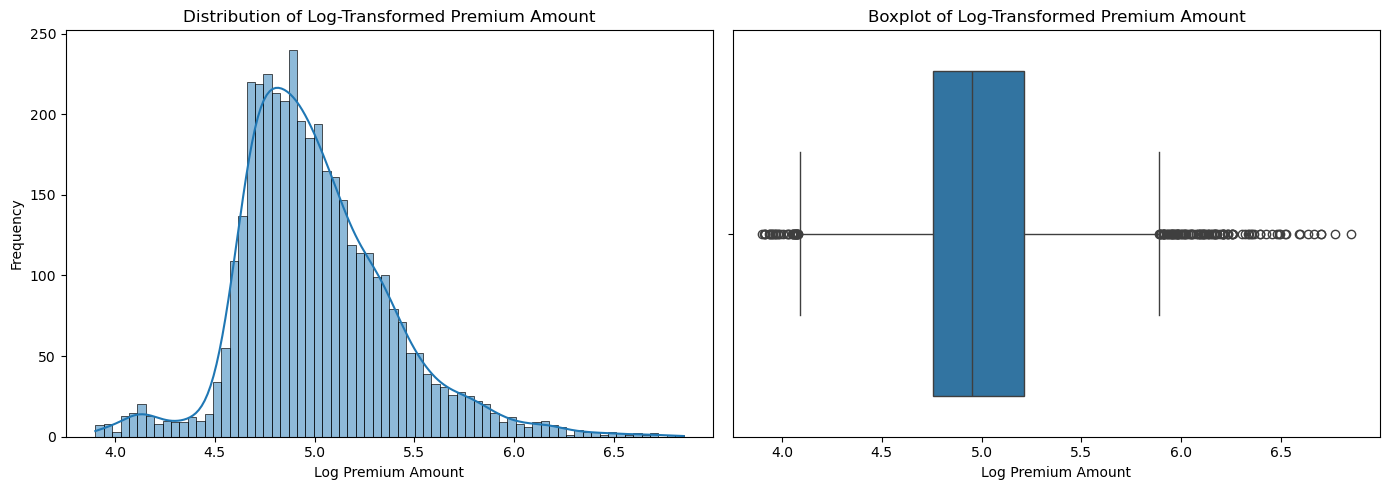

In [7]:
# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['Premium Amount'], bins=70, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Log-Transformed Premium Amount")
axes[0].set_xlabel("Log Premium Amount")
axes[0].set_ylabel("Frequency")

# Boxplot
sns.boxplot(x=df['Premium Amount'], ax=axes[1])
axes[1].set_title("Boxplot of Log-Transformed Premium Amount")
axes[1].set_xlabel("Log Premium Amount")

plt.tight_layout()

## STEP 3: Model Training & Performance Evaluation
In this task, we will use XGBoost to model premium values and make predictions for the reasons explained below:
- Handles missing values internally: There is no need to impute missing data manually — XGBoost learns the best path for missing values during tree splits.
- Robust to skewed numerical features: Tree-based models split data by thresholds, not by assuming normality (unlike linear models), so skewness is less of a problem.
- XGBoost optimizes relatively fast, even for large datasets, and avoids overfitting by regularization

In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping

In [43]:
cols_selection = ['PREMISES_BATHROOMS', 'PREMISES_BEDROOMS','PREMISES_PROPERTY_TYPE',
                  'PREMISES_REBUILD_COST','PREMISES_YEARS_RESIDENCY','PREMISES_YEAR_BUILT',
                  'PREMISES_NEIGHBOURHOOD_WATCH_IND','Premium Amount']
df_final = df[cols_selection] 

category_feats = df_final.select_dtypes(include=["object"]).columns.tolist()
df_final[category_feats] = df_final[category_feats].astype("category")

/tmp/ipykernel_903201/1480776706.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[category_feats] = df_final[category_feats].astype("category")


In [44]:

def model(X_train, y_train):
    """ Trains XGBoost with default parameters and returns the fitted model. Those default parameters are based on 
    common best practices for regression tasks, but can be further tuned for better performance.

    Args:
    X_train: Training features
    y_train: Training target variable

    Returns:
    model: Fitted XGBoost regression model
    """
    # Cross-validation on training data only
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # build the model with default parameters
    model = XGBRegressor(
        enable_categorical=True,
        tree_method="hist",  # Optimized for speed
        max_depth=6,
        learning_rate=0.05,
        n_estimators=1000,
        colsample_bytree=0.9,
        subsample=0.9,
        eval_metric="rmse",
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    print("CV RMSE:", -cv_scores.mean())

    model.fit(X_train, y_train)
    return model


def model_tuned(X_train, y_train, n_iter=20):
    """
    Trains XGBoost with RandomizedSearchCV and returns predictions.

    Args:
    X_train: Training features
    y_train: Training target variable
    n_iter: Number of parameter combinations to try in RandomizedSearchCV

    Returns:
        best_model: trained model
    """

    # Cross-validation on training data only
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        "max_depth": randint(3, 10),
        "learning_rate": uniform(0.01, 0.2),
        "n_estimators": randint(500, 2000),
        "subsample": uniform(0.7, 0.3),  # ranges from 0.7 to 1.0
        "colsample_bytree": uniform(0.7, 0.3),

    }

    model = XGBRegressor(
        enable_categorical=True,
        tree_method="hist",
        eval_metric="rmse",
        random_state=42
    )

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    
    print("Best parameters:", random_search.best_params_)
    print("Best CV score:", random_search.best_score_)

    return best_model



In [45]:
def train_model(X_train, y_train, model_type="default", n_iter=20):
    """
    Wrapper function to choose between default and tuned XGBoost models.

    Args:
        X_train: Training features
        y_train: Training target variable
        model_type: "default" or "tuned"
        n_iter: Number of iterations for tuning (only used if tuned)

    Returns:
        Trained model
    """

    if model_type == "default":
        return model(X_train, y_train)

    elif model_type == "tuned":
        return model_tuned(X_train, y_train, n_iter=n_iter)

    else:
        raise ValueError("model_type must be 'default' or 'tuned'")
    

def predict_premium(model, X):
    y_pred = model.predict(X)
    return y_pred

### Case 1: Baseline model - property data
- In case 1, We test the model `only on property dataset` without tuning, using default parameters that are based on common best practices

In [46]:
# Define Features and Target
X = df_final.drop(columns=["Premium Amount"])
y = df_final["Premium Amount"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_model = train_model(X_train, y_train, model_type="default")
y_pred = predict_premium(best_model, X_test)

CV RMSE: 0.33529885148475935


In [14]:
## Convert log values buck to actual ones for better interpretability
y_pred_values = np.expm1(y_pred)
y_test_values = np.expm1(y_test)

### Model performance

In [39]:
def scatterplot(y_test, y_pred):
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel('Actual Premium')
    plt.ylabel('Predicted Premium')
    plt.title('Actual vs Predicted Premium')

def plot_val_curve(val_curve):
    train_rmse = val_curve['validation_0']['rmse']
    val_rmse = val_curve['validation_1']['rmse']

    plt.figure()
    plt.plot(train_rmse, label="Train RMSE")
    plt.plot(val_rmse, label="Validation RMSE")

    plt.xlabel("Boosting Rounds")
    plt.ylabel("RMSE")
    plt.title("XGBoost Training vs Validation Performance")
    plt.legend()
    plt.show()

def validation_curve(best_model, X_train, y_train, X_test, y_test):
        best_model.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                )

        results = best_model.evals_result()
        plot_val_curve(results)
        return results

def feature_importance(X):
    """ Check features contribution

    Args:
        X: List of features
    """
    feature_importance_df = pd.DataFrame(index=X.columns)
    feature_importance_df["importance"] = best_model.feature_importances_
    feature_importance_df.sort_values("importance", ascending=False, inplace=True)

    ## plot feature importance
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=feature_importance_df["importance"], 
        y=feature_importance_df.index, 
        palette="YlOrRd_r"
    )
    plt.ylabel("Features")
    plt.xlabel("Importance")
    plt.title("Feature Importance from XGBoost Model");

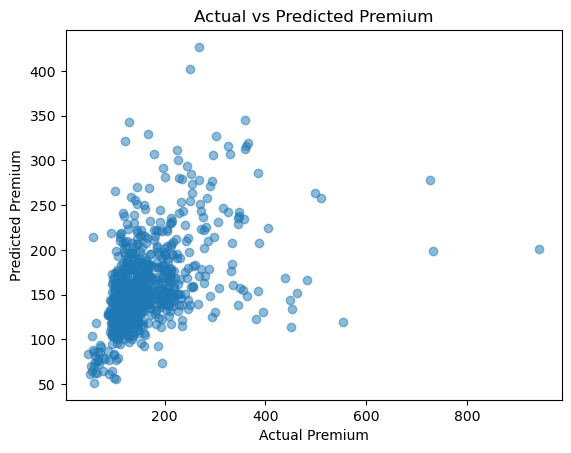

In [16]:
scatterplot(y_test_values, y_pred_values)

[0]	validation_0-rmse:0.36989	validation_1-rmse:0.38200
[1]	validation_0-rmse:0.36274	validation_1-rmse:0.37575
[2]	validation_0-rmse:0.35663	validation_1-rmse:0.37014
[3]	validation_0-rmse:0.35110	validation_1-rmse:0.36493
[4]	validation_0-rmse:0.34562	validation_1-rmse:0.35972
[5]	validation_0-rmse:0.34089	validation_1-rmse:0.35575
[6]	validation_0-rmse:0.33585	validation_1-rmse:0.35139
[7]	validation_0-rmse:0.33211	validation_1-rmse:0.34802
[8]	validation_0-rmse:0.32802	validation_1-rmse:0.34412
[9]	validation_0-rmse:0.32434	validation_1-rmse:0.34106


[10]	validation_0-rmse:0.32068	validation_1-rmse:0.33758
[11]	validation_0-rmse:0.31708	validation_1-rmse:0.33458
[12]	validation_0-rmse:0.31382	validation_1-rmse:0.33197
[13]	validation_0-rmse:0.31093	validation_1-rmse:0.32949
[14]	validation_0-rmse:0.30815	validation_1-rmse:0.32714
[15]	validation_0-rmse:0.30565	validation_1-rmse:0.32539
[16]	validation_0-rmse:0.30335	validation_1-rmse:0.32377
[17]	validation_0-rmse:0.30086	validation_1-rmse:0.32234
[18]	validation_0-rmse:0.29896	validation_1-rmse:0.32099
[19]	validation_0-rmse:0.29695	validation_1-rmse:0.31929
[20]	validation_0-rmse:0.29497	validation_1-rmse:0.31779
[21]	validation_0-rmse:0.29305	validation_1-rmse:0.31636
[22]	validation_0-rmse:0.29128	validation_1-rmse:0.31521
[23]	validation_0-rmse:0.28970	validation_1-rmse:0.31421
[24]	validation_0-rmse:0.28835	validation_1-rmse:0.31325
[25]	validation_0-rmse:0.28699	validation_1-rmse:0.31239
[26]	validation_0-rmse:0.28574	validation_1-rmse:0.31163
[27]	validation_0-rmse:0.28450	

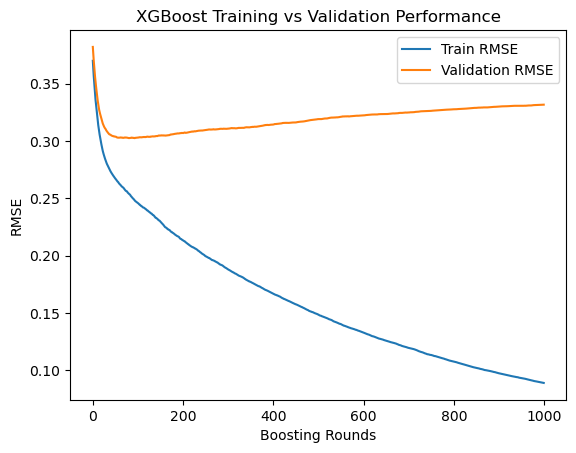

In [17]:
val_curve = validation_curve(best_model, X_train, y_train, X_test, y_test)

/tmp/ipykernel_880085/4142100237.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


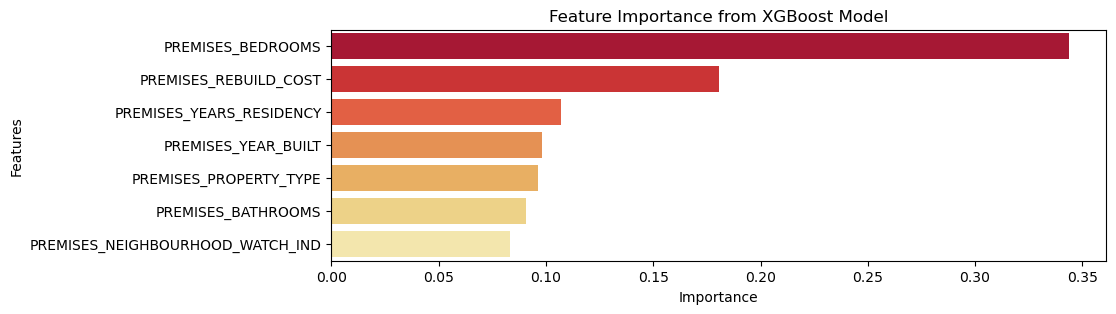

In [19]:
feature_importance(X)

### Evaluation

The performance of the model is evaluated based on the following metrics:
- **Mean absolute error (MAE):** This is the difference between actual and predicted values.  We get an overall idea of how far off the model is
- **Root Mean Squared Error (RMSE)** This is similar to MAE but it penalizes large error more heavily. RMSE is very important because if we have large pricing errors , that's a big financial risk
- **R^2** It measures how well we capture premium variation. The closer to 1 the better our predictions
- **Mean Absolute Percentage Error (MAPE)** It mesures relative error (%) compared to absolute error (£). It highlights big errors in predictions

In [34]:
def metrics(y_test, y_pred):
    # MAE
    mae = mean_absolute_error(y_test, y_pred)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # R²
    r2 = r2_score(y_test, y_pred)

    # Mean Absolute Percentage Error
    epsilon = 1e-6
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    return mae, rmse, mape


def metrics_by_premises(X_test, y_test, y_pred):
    """ Evaluate the error based on the premise type

    Args:
        X_test: The test dataset used for prediction
        y_test: Actual premiums
        y_pred: Predictions
    """
    eval_df = X_test.copy()
    eval_df["actual"] = y_test
    eval_df["predicted"] = y_pred
    eval_df["error"] = eval_df["predicted"] - eval_df["actual"]
    eval_df["MAE"] = np.abs(eval_df["error"])
    eval_df["MAPE (%)"] = (eval_df["MAE"] / (eval_df["actual"] + 1e-6)) * 100

    eval_per_premise = eval_df.groupby("PREMISES_PROPERTY_TYPE").agg({
        "MAE": "mean",
        "MAPE (%)": "mean",
        "error": "mean"
    })
    return eval_df, eval_per_premise

In [21]:
mae, rmse, mape = metrics(y_test_values, y_pred_values)
df_metric, df_metric_grouped = metrics_by_premises(X_test, y_test_values, y_pred_values)

MAE: 43.22
RMSE: 72.69
R²: 0.1847
MAPE: 25.40%


/tmp/ipykernel_880085/2177437456.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_per_premise = eval_df.groupby("PREMISES_PROPERTY_TYPE").agg({


In [22]:
df_metric_grouped

,MAE,MAPE (%),error
PREMISES_PROPERTY_TYPE,,,
Bungalow,39.215876,23.468737,-3.250901
Flat,28.335064,49.153322,22.905962
House - Detached,51.941244,26.543773,-9.611940
House - Semi-detached,37.617331,23.483644,-2.310293
House - Terraced,42.322962,27.142578,2.869710


### Case 2: Model tuning: property data
- In case 2, we tune the model's hyperparameters on property data. After tuning, the model select the best hyperparameters that produce the highest accuracy

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_model = train_model(X_train, y_train, model_type="tuned")
y_pred = predict_premium(best_model, X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   1.5s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   1.9s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   1.3s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   3.0s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   3.1s
[CV] END colsample_bytree=0.7468055921327309, learning_rate=0.041198904067240534, max_depth=5, n_estimators=1982, subsample=0.95

In [48]:
## Convert log values buck to actual ones for better interpretability
y_pred_values = np.expm1(y_pred)
y_test_values = np.expm1(y_test)

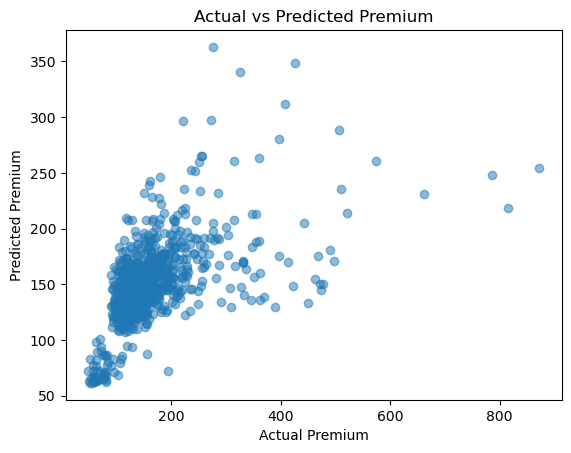

In [28]:
scatterplot(y_test_values, y_pred_values)

[0]	validation_0-rmse:0.37263	validation_1-rmse:0.40086
[1]	validation_0-rmse:0.37131	validation_1-rmse:0.39936
[2]	validation_0-rmse:0.37004	validation_1-rmse:0.39787
[3]	validation_0-rmse:0.36889	validation_1-rmse:0.39654
[4]	validation_0-rmse:0.36764	validation_1-rmse:0.39511
[5]	validation_0-rmse:0.36654	validation_1-rmse:0.39382
[6]	validation_0-rmse:0.36532	validation_1-rmse:0.39243
[7]	validation_0-rmse:0.36441	validation_1-rmse:0.39136
[8]	validation_0-rmse:0.36321	validation_1-rmse:0.38997
[9]	validation_0-rmse:0.36216	validation_1-rmse:0.38876
[10]	validation_0-rmse:0.36098	validation_1-rmse:0.38738
[11]	validation_0-rmse:0.35984	validation_1-rmse:0.38607
[12]	validation_0-rmse:0.35871	validation_1-rmse:0.38479
[13]	validation_0-rmse:0.35760	validation_1-rmse:0.38354
[14]	validation_0-rmse:0.35654	validation_1-rmse:0.38232
[15]	validation_0-rmse:0.35562	validation_1-rmse:0.38124
[16]	validation_0-rmse:0.35460	validation_1-rmse:0.38008
[17]	validation_0-rmse:0.35358	validation

[37]	validation_0-rmse:0.33701	validation_1-rmse:0.35971
[38]	validation_0-rmse:0.33642	validation_1-rmse:0.35905
[39]	validation_0-rmse:0.33572	validation_1-rmse:0.35823
[40]	validation_0-rmse:0.33500	validation_1-rmse:0.35737
[41]	validation_0-rmse:0.33429	validation_1-rmse:0.35652
[42]	validation_0-rmse:0.33359	validation_1-rmse:0.35571
[43]	validation_0-rmse:0.33295	validation_1-rmse:0.35494
[44]	validation_0-rmse:0.33230	validation_1-rmse:0.35421
[45]	validation_0-rmse:0.33165	validation_1-rmse:0.35344
[46]	validation_0-rmse:0.33112	validation_1-rmse:0.35286
[47]	validation_0-rmse:0.33050	validation_1-rmse:0.35217
[48]	validation_0-rmse:0.32991	validation_1-rmse:0.35145
[49]	validation_0-rmse:0.32928	validation_1-rmse:0.35070
[50]	validation_0-rmse:0.32870	validation_1-rmse:0.35000
[51]	validation_0-rmse:0.32811	validation_1-rmse:0.34935
[52]	validation_0-rmse:0.32754	validation_1-rmse:0.34870
[53]	validation_0-rmse:0.32695	validation_1-rmse:0.34799
[54]	validation_0-rmse:0.32638	

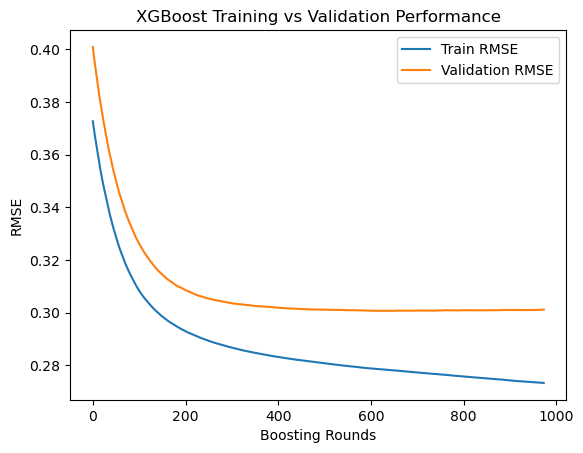

In [29]:
val_curve = validation_curve(best_model, X_train, y_train, X_test, y_test)

In [30]:
mae, rmse, mape = metrics(y_test_values, y_pred_values)
df_metric, df_metric_grouped = metrics_by_premises(X_test, y_test_values, y_pred_values)

MAE: 39.75
RMSE: 73.25
R²: 0.2769
MAPE: 21.04%


/tmp/ipykernel_880085/2177437456.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_per_premise = eval_df.groupby("PREMISES_PROPERTY_TYPE").agg({


/tmp/ipykernel_903201/2788226073.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


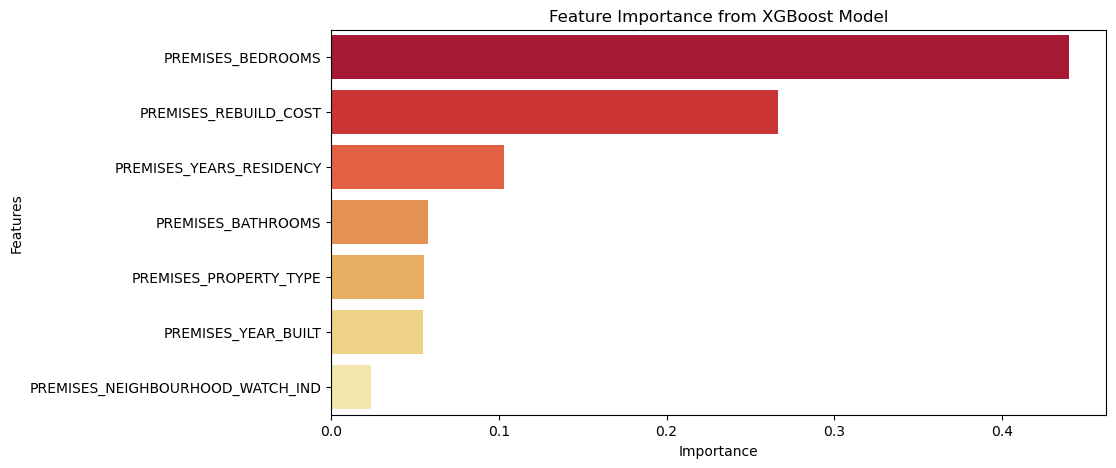

In [49]:
feature_importance(X)

### Case 3:  Model tuning: property data + flood risk data
- In case 3, we combine flood risk data with the property data and we use the tuned model. By combining both different datasets, we expect the model performance to increase

In [32]:
cols_selection = ['PREMISES_BATHROOMS', 'PREMISES_BEDROOMS','PREMISES_PROPERTY_TYPE',
                  'PREMISES_REBUILD_COST','PREMISES_YEARS_RESIDENCY','PREMISES_YEAR_BUILT',
                  'PREMISES_NEIGHBOURHOOD_WATCH_IND','LATITUDE','LONGITUDE','FLOOD_RISK_1','FLOOD_RISK_2','FLOOD_RISK_3',
                  'Premium Amount']
df_final = df[cols_selection]

category_feats = df_final.select_dtypes(include=["object"]).columns.tolist()
df_final[category_feats] = df_final[category_feats].astype("category")

/tmp/ipykernel_880085/2285881210.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[category_feats] = df_final[category_feats].astype("category")


In [33]:
# Define Features and Target
X = df_final.drop(columns=["Premium Amount"])
y = df_final["Premium Amount"]


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_model = train_model(X_train, y_train, model_type="tuned")
y_pred = predict_premium(best_model, X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.7s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.8s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.9s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.1s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.8s
[CV] END colsample_bytree=0.7468055921327309, learning_rate=0.041198904067240534, max_depth=5, n_estimators=1982, subsample=0.9598528437324805; total time=   2.3s
[CV] END colsample_bytree=0

In [35]:
## Convert log values buck to actual ones for better interpretability
y_pred_values = np.expm1(y_pred)
y_test_values = np.expm1(y_test)

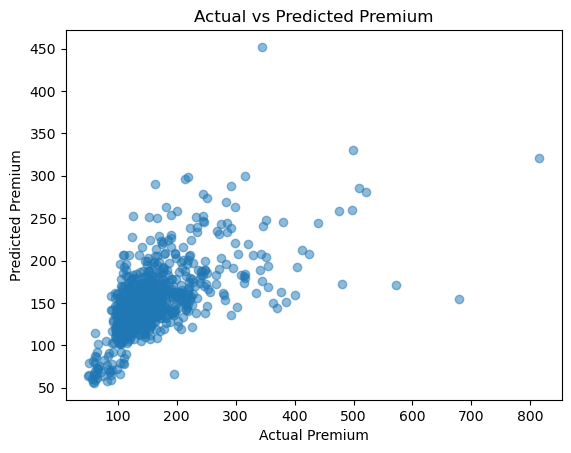

In [36]:
scatterplot(y_test_values, y_pred_values)

[0]	validation_0-rmse:0.37888	validation_1-rmse:0.37716
[1]	validation_0-rmse:0.37761	validation_1-rmse:0.37587
[2]	validation_0-rmse:0.37610	validation_1-rmse:0.37438
[3]	validation_0-rmse:0.37465	validation_1-rmse:0.37292
[4]	validation_0-rmse:0.37323	validation_1-rmse:0.37154
[5]	validation_0-rmse:0.37181	validation_1-rmse:0.37009
[6]	validation_0-rmse:0.37041	validation_1-rmse:0.36872
[7]	validation_0-rmse:0.36907	validation_1-rmse:0.36738
[8]	validation_0-rmse:0.36793	validation_1-rmse:0.36622
[9]	validation_0-rmse:0.36662	validation_1-rmse:0.36497
[10]	validation_0-rmse:0.36534	validation_1-rmse:0.36371
[11]	validation_0-rmse:0.36405	validation_1-rmse:0.36240
[12]	validation_0-rmse:0.36280	validation_1-rmse:0.36118
[13]	validation_0-rmse:0.36158	validation_1-rmse:0.35999
[14]	validation_0-rmse:0.36037	validation_1-rmse:0.35884
[15]	validation_0-rmse:0.35926	validation_1-rmse:0.35771
[16]	validation_0-rmse:0.35807	validation_1-rmse:0.35649
[17]	validation_0-rmse:0.35715	validation

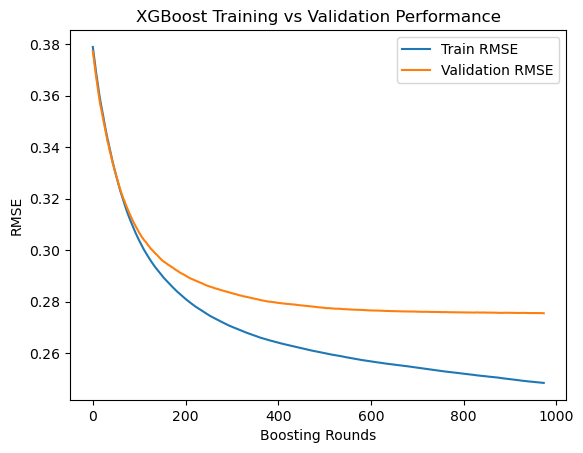

In [37]:
val_curve = validation_curve(best_model, X_train, y_train, X_test, y_test)

In [39]:
mae, rmse, mape = metrics(y_test_values, y_pred_values)
df_metric, df_metric_grouped = metrics_by_premises(X_test, y_test_values, y_pred_values)

MAE: 36.10
RMSE: 59.86
R²: 0.3626
MAPE: 20.78%


/tmp/ipykernel_880085/2177437456.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_per_premise = eval_df.groupby("PREMISES_PROPERTY_TYPE").agg({


In [40]:
df_metric_grouped

,MAE,MAPE (%),error
PREMISES_PROPERTY_TYPE,,,
Bungalow,31.831340,19.457535,-1.510865
Flat,21.220732,20.030449,-17.416873
House - Detached,45.894523,23.839028,-9.659426
House - Semi-detached,29.779919,18.313844,-5.694309
House - Terraced,34.534083,20.801785,-9.264722


/tmp/ipykernel_880085/4142100237.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


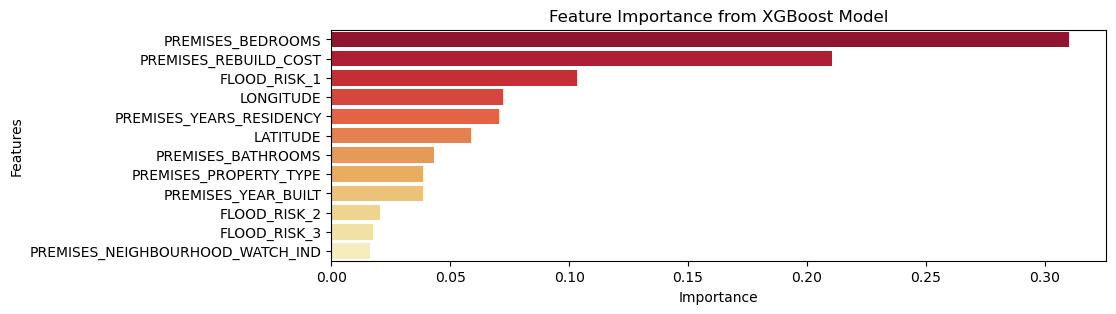

In [41]:
feature_importance(X)

### Case 4: Model tuning: property data + flood risk data + engineered features

In [23]:
cols_selection = ['PREMISES_BATHROOMS', 'PREMISES_BEDROOMS','PREMISES_PROPERTY_TYPE',
                  'PREMISES_REBUILD_COST','PREMISES_YEARS_RESIDENCY','PREMISES_YEAR_BUILT',
                  'PREMISES_NEIGHBOURHOOD_WATCH_IND','LATITUDE','LONGITUDE','FLOOD_RISK_1',
                  'FLOOD_RISK_2','FLOOD_RISK_3','PREMISES_AGE','ratio_rooms_over_bath','new_homeowner','long_term_resident',
                  'Premium Amount']
df_final = df[cols_selection]

category_feats = df_final.select_dtypes(include=["object"]).columns.tolist()
df_final[category_feats] = df_final[category_feats].astype("category")

/tmp/ipykernel_903201/3987451906.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[category_feats] = df_final[category_feats].astype("category")


In [25]:
# Define Features and Target
X = df_final.drop(columns=["Premium Amount"])
y = df_final["Premium Amount"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_model = train_model(X_train, y_train, model_type="tuned")
y_pred = predict_premium(best_model, X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   3.4s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.7s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.0s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   2.5s
[CV] END colsample_bytree=0.7468055921327309, learning_rate=0.041198904067240534, max_depth=5, n_estimators=1982, subsample=0.9598528437324805; total time=   2.4s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.20014286128198325, max_depth=5, n_estimators=1595, subsample=0.8795975452591109; total time=   3.2s
[CV] END colsample_bytree=0

In [32]:
## Convert log values buck to actual ones for better interpretability
y_pred_values = np.expm1(y_pred)
y_test_values = np.expm1(y_test)

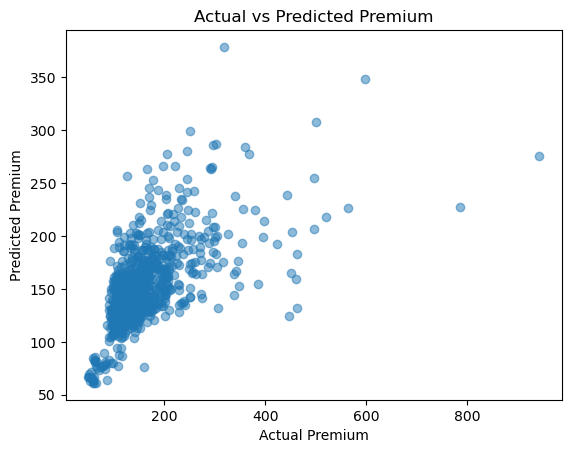

In [36]:
scatterplot(y_test_values, y_pred_values)

[0]	validation_0-rmse:0.37586	validation_1-rmse:0.38830
[1]	validation_0-rmse:0.37443	validation_1-rmse:0.38687
[2]	validation_0-rmse:0.37320	validation_1-rmse:0.38560
[3]	validation_0-rmse:0.37201	validation_1-rmse:0.38440
[4]	validation_0-rmse:0.37063	validation_1-rmse:0.38305
[5]	validation_0-rmse:0.36929	validation_1-rmse:0.38175
[6]	validation_0-rmse:0.36823	validation_1-rmse:0.38071
[7]	validation_0-rmse:0.36688	validation_1-rmse:0.37936
[8]	validation_0-rmse:0.36558	validation_1-rmse:0.37811
[9]	validation_0-rmse:0.36431	validation_1-rmse:0.37687
[10]	validation_0-rmse:0.36323	validation_1-rmse:0.37580
[11]	validation_0-rmse:0.36216	validation_1-rmse:0.37472
[12]	validation_0-rmse:0.36097	validation_1-rmse:0.37351
[13]	validation_0-rmse:0.35978	validation_1-rmse:0.37235
[14]	validation_0-rmse:0.35888	validation_1-rmse:0.37149
[15]	validation_0-rmse:0.35794	validation_1-rmse:0.37055
[16]	validation_0-rmse:0.35677	validation_1-rmse:0.36937
[17]	validation_0-rmse:0.35566	validation

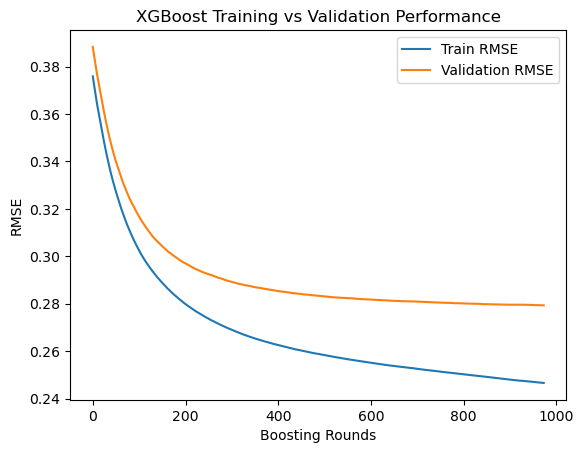

In [37]:
val_curve = validation_curve(best_model, X_train, y_train, X_test, y_test)

In [41]:
mae, rmse, mape = metrics(y_test_values, y_pred_values)
df_metric, df_metric_grouped = metrics_by_premises(X_test, y_test_values, y_pred_values)

MAE: 36.96
RMSE: 65.14
R²: 0.3439
MAPE: 20.58%


/tmp/ipykernel_903201/2177437456.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_per_premise = eval_df.groupby("PREMISES_PROPERTY_TYPE").agg({


In [42]:
df_metric_grouped

,MAE,MAPE (%),error
PREMISES_PROPERTY_TYPE,,,
Bungalow,36.734473,21.968662,-5.274786
Flat,9.974889,18.359605,9.333700
House - Detached,46.464364,21.185053,-18.139721
House - Semi-detached,32.733383,20.027324,-6.602021
House - Terraced,30.038159,19.071437,-0.398160


/tmp/ipykernel_903201/2788226073.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


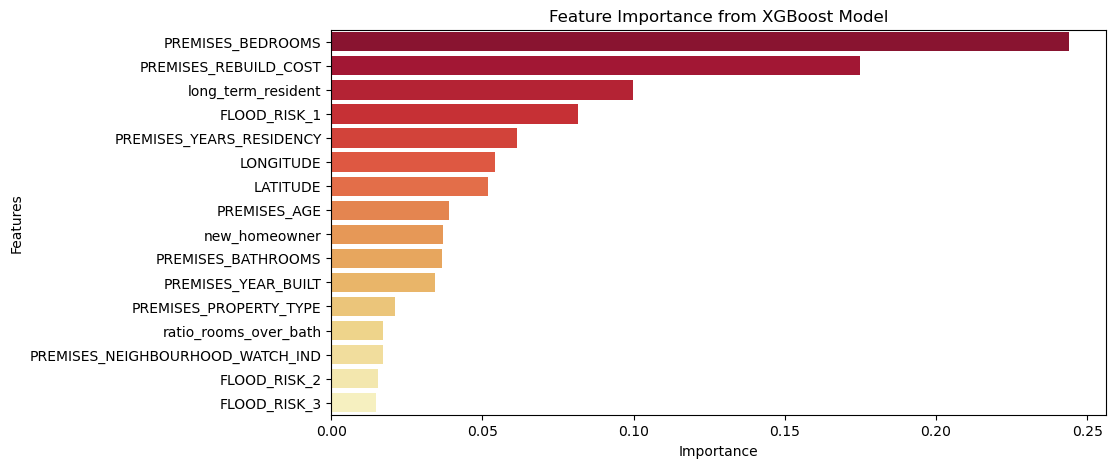

In [40]:
feature_importance(X)

**Key insights**

Model performance
- In Case 1, the model was used as a baseline (trained only on property data) where we have used default parameters to train the model. We can observe the following
    - **Validation curve:** During training, the training loss were constantly decreasing reaching a very low error. On the other hand, the validation loss stopped decreasing abruptly which is an indication of model overfitting.
    - **Metrics:** MAE: 43 (on average we are far off £43), RMSE: 72, MAPE: 25%
    - **feature importance:** Top features that contributed the most: `1. PREMISES_BEDROOMS`, `2.PREMISES_REBUILD_COST`, `3. PREMISES_YEARS_RESIDENCY`

    For the other cases, we can see how the model have improved in every aspect when we included flood risk and the engineered features. FOr the final case (case 4) we observe the following:
    - **Validation curve:** We observe significant improvement on teh valdiation curve. This is what we expect to see. That was a result of model tuning where the appropriate hyperparameters were chosen
    - **Metrics:** MAE: 36 (on average we are far off £36), RMSE: 65, MAPE: 20%
    - **feature importance:** Top features that contributed the most: `1. PREMISES_BEDROOMS`, `2.PREMISES_REBUILD_COST`, `3. long_term_resident`, `4. Fllod risk 1`. We see that the flood risk 2 and flood risk 3 did not contribute much


## Improvements
- **Improve Project Structure and Maintainability:** We need to structure the project into modular, reproducible, and maintainable pipeline. This ensures that as the project grows, it remains clean, easy to extend, and production-ready
- **Improve performance:** Use python package **DASK** for parallel processing
- **Tuning:** Perform large-scale hyperparameter tuning using frameworks like `Optuna` or `Ray Tune`.

**Additional datasets** 

Below is some recommendation with some additionaly data we could posibly use to improve the model predictions
- **Distance to caostline:** Given that we have coordiantes for each premise, we could calculate the distance of each building to the coast or river. Buildigns closer to rivers have higher propability of being affected by a flood
- **Fire risk:** Distance to woodland areas. We could use MODIS satellite fire risk product to estimate the probabilty of fire in combination to house proximity.
- **Digital elevation model**: Houses located in higher elevation are less likely to get flooded
- **Deprivation index**: Deprivation index for the whole Uk can be downloaded by `NOMIS` website

## Analysis as scale
- Develop automated ML end-to-end pipelines. Use Apache Airflow for scheduling and orchestration. Airflow allows us to do the following:

        -Pull new insurance records
        -Clean / transform features
        -Load trained model
        -Run predictions
        -Store results (DB / API)
        -Monitor / alert

    Airflow turns this into a repeatable, production-grade pipeline.

- Use Docker to package the model and its dependencies into a Docker container and deploy it on cloud platforms for scalable, reliable production serving.
- Use Cloud Platforms (AWS, GCP, Azure) to deploy the solution. We can use services such as AWS SageMaker for robust training, deployment, and monitoring in production environments (Cloudwatch).